In [38]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import numpy as np
import pandas as pd

In [39]:
# --- データ定義 ---
data_dir = "C:/Users/takat/Desktop/sotuken/dat_to_images_64"

# ラベルがついているPBMファイル
labeled_pbm = [
    # Mild
    'AF483470.1.pbm', 'EF192393.1.pbm', 'EF192394.1.pbm', 'EF580923.1.pbm', 'EU879915.1.pbm',
    'EU879916.1.pbm', 'JQ806338.1.pbm', 'KF418767.1.pbm', 'KR611355.1.pbm', 'KT987925.1.pbm',
    'LC388852.1.pbm', 'LC388854.1.pbm', 'M25199.1.pbm', 'MG450357.1.pbm', 'Y09575.1.pbm',
    # Moderate
    'AF454395.1.pbm', 'KF683200.1.pbm', 'KJ857496.1.pbm', 'KR611360.1.pbm', 'M88678.1.pbm',
    'X17268.1.pbm', 'GQ853461.1.pbm', 'EU879913.1.pbm',
    # Severe
    'AJ634596.1.pbm', 'AY518939.1.pbm', 'AY532801.1.pbm', 'DD220185.1.pbm', 'FR851463.1.pbm',
    'JX280944.1.pbm', 'U23060.1.pbm', 'X58388.1.pbm', 'X76846.1.pbm', 'X97387.1.pbm',
    'Y09383.1.pbm', 'LC523672.1.pbm', 'LC523675.1.pbm', 'LC523676.1.pbm'
]

# 重症度ラベル（0: mild, 1: moderate, 2: severe）
labels = [
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,   # mild (15)
    1, 1, 1, 1, 1, 1, 1, 1,                       # moderate (8)
    2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2       # severe (14)
]
label_dict = dict(zip(labeled_pbm, labels))

In [40]:
# --- PBMデータセットの定義 ---
class PBM_Dataset(Dataset):
    def __init__(self, folder, label_dict=None, transform=None):
        self.folder = folder
        self.label_dict = label_dict
        self.transform = transform
        self.files = [f for f in os.listdir(folder) if f.endswith(".pbm")]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filename = self.files[idx]
        img_path = os.path.join(self.folder, filename)
        image = Image.open(img_path).convert('L')
        if self.transform:
            image = self.transform(image)
        label = self.label_dict.get(filename, -1)
        return image, label, filename

# --- 画像の前処理 ---
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# --- データセットの準備 ---
dataset = PBM_Dataset(data_dir, label_dict, transform)
labeled_idx = [i for i, f in enumerate(dataset.files) if f in label_dict]
unlabeled_idx = [i for i, f in enumerate(dataset.files) if f not in label_dict]

labeled_dataset = Subset(dataset, labeled_idx)
unlabeled_dataset = Subset(dataset, unlabeled_idx)

print(f"全データ数: {len(dataset)}")
print(f"ラベルあり: {len(labeled_dataset)}")
print(f"ラベルなし: {len(unlabeled_dataset)}")

全データ数: 307
ラベルあり: 37
ラベルなし: 270


In [41]:
class CNN(nn.Module):
    def __init__(self, num_classes=3):
        super(CNN, self).__init__()
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, stride=2)
        self.conv1 = nn.Conv2d(1, 8, 3)
        self.conv2 = nn.Conv2d(8, 16, 3)
        self.fc1 = nn.Linear(16 * 14 * 14, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x) # self.dropout(x) の呼び出しを削除
        return x

In [42]:
def jackknife_training(model_class, labeled_dataset, params):
    all_preds = []
    all_labels = []

    # パラメータを展開
    device = params['device']
    num_epochs = params['num_epochs']
    batch_size = params['batch_size']
    learning_rate = params['learning_rate']
    accuracy = []
    print("jackknife start")
    for i in range(len(labeled_dataset)):

        # 1つを検証用、残りを学習用として分割
        train_idx = [j for j in range(len(labeled_dataset)) if j != i]
        val_idx = [i]
        train_loader = DataLoader(Subset(labeled_dataset, train_idx), batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(Subset(labeled_dataset, val_idx), batch_size=1)

        # モデル、最適化手法、損失関数を初期化
        model = model_class(num_classes=3).to(device)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.CrossEntropyLoss()

        # 学習ループ
        for epoch in range(num_epochs):
            model.train()
            for imgs, lbls, _ in train_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                optimizer.zero_grad()
                outputs = model(imgs)
                loss = criterion(outputs, lbls)
                loss.backward()
                optimizer.step()

        # 検証（予測）
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for imgs, lbls, _ in val_loader:
                outputs = model(imgs.to(device))
                _, pred = torch.max(outputs, 1)
                correct += (pred.cpu() == lbls).sum().item()
                total +=lbls.size(0)
                all_preds.append(pred.cpu().numpy())
                all_labels.append(lbls.cpu().numpy())

        acc = correct/total
        accuracy.append(acc)
        print(f"{i} Accuracy:{acc:.3f}")

    ave_acc = np.mean(accuracy)
    print(f"average accracy:{ave_acc:.3f}")
    print("jackknife finish")
    # 予測結果と正解ラベルをフラットなNumpy配列にして返す
    return np.concatenate(all_preds), np.concatenate(all_labels)


Using device: cpu

--- 1. Training final model on ALL labeled data ---


Final Model Training:  20%|██        | 2/10 [00:00<00:00, 13.91it/s]

Epoch [1/10], Loss: 1.0883, Acc: 0.405
Epoch [2/10], Loss: 1.0740, Acc: 0.405
Epoch [3/10], Loss: 1.0596, Acc: 0.378


Final Model Training:  40%|████      | 4/10 [00:00<00:00, 13.76it/s]

Epoch [4/10], Loss: 1.0460, Acc: 0.459
Epoch [5/10], Loss: 1.0282, Acc: 0.514


...

Epoch [6/10], Loss: 1.0470, Acc: 0.541


Final Model Training:  80%|████████  | 8/10 [00:00<00:00, 13.49it/s]

Epoch [7/10], Loss: 1.0084, Acc: 0.541
Epoch [8/10], Loss: 0.9965, Acc: 0.622
Epoch [9/10], Loss: 0.9782, Acc: 0.622


Final Model Training: 100%|██████████| 10/10 [00:00<00:00, 13.44it/s]


Epoch [10/10], Loss: 1.0175, Acc: 0.676


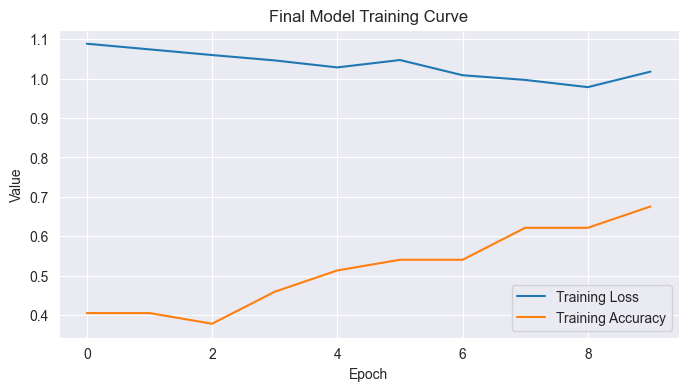

Predicting Unlabeled Data: 100%|██████████| 68/68 [00:00<00:00, 225.56it/s]


finish


In [43]:
if __name__ == "__main__":
    params = {
        "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
        "num_epochs": 10,
        "batch_size": 4,
        "learning_rate": 1e-4
    }
    label_map = {0: 'mild', 1: 'moderate', 2: 'severe'}
    print(f"Using device: {params['device']}")

    # --- (A) 全てのラベル付きデータで「最終モデル」を学習 ---
    print("\n--- 1. Training final model on ALL labeled data ---")
    final_train_loader = DataLoader(labeled_dataset, batch_size=params['batch_size'], shuffle=True)
    final_model = CNN(num_classes=3).to(params['device'])
    optimizer = optim.Adam(final_model.parameters(), lr=params['learning_rate'])
    criterion = nn.CrossEntropyLoss()

    train_loss = []
    train_acc = []

    final_model.train()
    for epoch in tqdm(range(params['num_epochs']), desc="Final Model Training"):
        running_loss = 0
        correct = 0
        total = 0

        for imgs, lbls, _ in final_train_loader:
            imgs, lbls = imgs.to(params['device']), lbls.to(params['device'])
            optimizer.zero_grad()
            outputs = final_model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()

            running_loss +=loss.item()
            _,preds = torch.max(outputs, 1)
            correct += (preds == lbls).sum().item()
            total += lbls.size(0)

        epoch_loss = running_loss/ len(final_train_loader)
        epoch_acc = correct/total
        train_loss.append(epoch_loss)
        train_acc.append(epoch_acc)
        print(f"Epoch [{epoch+1}/{params['num_epochs']}], Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.3f}")

    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,4))
    plt.plot(train_loss, label='Training Loss')
    plt.plot(train_acc, label='Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.legend()
    plt.title('Final Model Training Curve')
    plt.show()

    #学習したモデルでもう一回学習
    final_model.eval()
    all_results = []

    # ラベル付きデータローダー（ファイル名、正解ラベル、予測ラベルを取得）
    labeled_loader_for_eval = DataLoader(labeled_dataset, batch_size=params['batch_size'], shuffle=False)
    with torch.no_grad():
        for imgs, lbls, filenames in tqdm(labeled_loader_for_eval, desc="Predicting Labeled Data"):
            outputs = final_model(imgs.to(params['device']))
            _, preds = torch.max(outputs, 1)
            for i in range(len(filenames)):
                all_results.append({
                    "DataType": "Labeled",
                    "Filename": filenames[i],
                    "True_Severity": label_map[lbls[i].item()],
                    "Predicted_Severity": label_map[preds[i].item()]
                })

    # ラベルなしデータローダー（ファイル名、予測ラベルを取得）
    unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=params['batch_size'], shuffle=False)
    with torch.no_grad():
        for imgs, _, filenames in tqdm(unlabeled_loader, desc="Predicting Unlabeled Data"):
            outputs = final_model(imgs.to(params['device']))
            _, preds = torch.max(outputs, 1)
            for i in range(len(filenames)):
                all_results.append({
                    "DataType": "Unlabeled",
                    "Filename": filenames[i],
                    "True_Severity": None,  # 正解ラベルはないのでNone
                    "Predicted_Severity": label_map[preds[i].item()]
                })

    # --- (C) 予測結果を1つのCSVファイルに保存 ---
    df_final = pd.DataFrame(all_results)
    df_final.to_csv('all_data_predictions.csv', index=False, encoding='utf-8-sig')
    print("finish")
